# 00 · Warm-up: why $H = 1/2$ is a modelling choice

Black–Scholes, Heston, SABR: every model you have calibrated is driven by Brownian motion, and each
inherits one number from it that nobody asks you to calibrate, namely how rough the driving path is,
fixed silently at $H = 1/2$.

**The question.** What does $[W]_t = t$ assert about a path, how do you check it in ten lines of
code, and what would break if it were false?

The plan for the series is in [ROADMAP.md](ROADMAP.md). Everything here is simulated: **no market
data appears in this notebook**, and it runs top to bottom from a clean kernel with one seed, set
below.

In [1]:
import inspect
from math import gamma

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

from roughvol import paths, variation
from roughvol.plotting import ACCENT, ACCENT_ALT, FIGSIZE_DIAG, FIGSIZE_WIDE, style

style()          # this repository's matplotlib defaults, applied once

SEED = 20260917  # every path in this notebook descends from this one integer

## 1. Quadratic variation, and what "rough" means

Start where the money is. You are long a European option and delta-hedge it to expiry at
Black–Scholes implied volatility $\sigma_{\text{imp}}$, while the underlying realises
$\sigma_{\text{real}}$. Your profit is

$$
\Pi_T \;=\; \tfrac{1}{2}\int_0^T \Gamma_t\, S_t^2 \left(\sigma_{\text{real},t}^2 -
\sigma_{\text{imp}}^2\right) dt ,
$$

a bet on *realised variance against implied*, weighted by gamma.

Three conventions do the work, and an interviewer will ask for all three. You are **long**, so
shorting flips the sign. $\Gamma_t$ is the *Black–Scholes* gamma at $\sigma_{\text{imp}}$, read
along the realised path. And $r = 0$. So hedged, the identity is **exact**.

Re-read $\sigma_{\text{real}}^2\,dt$: the **quadratic variation of the log price**, the limit of a
sum of squared returns as you sample more finely. "How much does this path wiggle at small scales?"
is a P&L question before it is a mathematics question. If the wiggle is not what Brownian motion
claims, the integral is not the trade you thought you had, and may not exist at all.

### The intuition: what you see when you zoom in

Take a curve you can differentiate and zoom in. It flattens: up close, the curve is a straight line.
That *is* what differentiable means.

A Brownian path refuses. Zoom in and you get another Brownian path, the same jagged mess at a
smaller scale.

Roughness is not about how ugly the picture looks. It is the **exchange rate between the two
zooms**: shrink the horizontal axis by a factor $c$ and the vertical wiggle shrinks only by
$\sqrt{c}$. That square root is $H = 1/2$, and it is the whole subject.

The rest follows from one experiment.

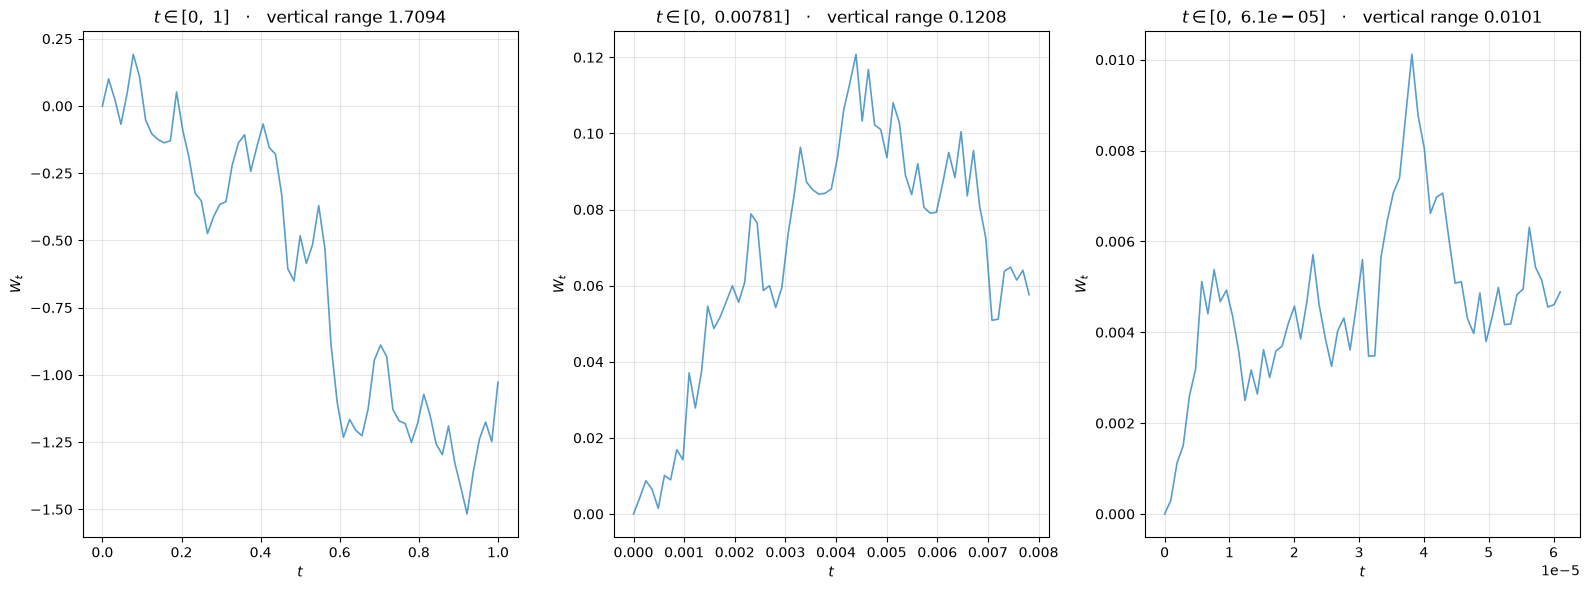

time shrinks by a factor of 128 between panels
vertical range shrinks by 14.2x then 11.9x
square root of the time zoom: sqrt(128) = 11.3


In [2]:
N_FINE = 2**20        # steps on the finest grid we will ever look at
T = 1.0
ZOOM = 2**7           # each panel zooms in by this factor in time (128x)

W = paths.brownian(n=N_FINE, T=T, m=1, seed=SEED)[0]   # one path, shape (N_FINE + 1,)
t = np.linspace(0.0, T, N_FINE + 1)                    # the matching grid

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
spans = []
for k, ax in enumerate(axes):
    width = N_FINE // ZOOM**k            # steps inside this window
    stride = width // 64                 # draw 64 segments in every panel, whatever the scale
    ts, ws = t[: width + 1 : stride], W[: width + 1 : stride]
    spans.append(np.ptp(ws))
    ax.plot(ts, ws, color=ACCENT, alpha=0.8)
    ax.set_title(f"$t \\in [0,\\ {width / N_FINE:.3g}]$   ·   vertical range {spans[-1]:.4f}")
    ax.set_xlabel("$t$")
    ax.set_ylabel("$W_t$")
fig.tight_layout()
plt.show()

print(f"time shrinks by a factor of {ZOOM} between panels")
print(f"vertical range shrinks by {spans[0] / spans[1]:.1f}x then {spans[1] / spans[2]:.1f}x")
print(f"square root of the time zoom: sqrt({ZOOM}) = {np.sqrt(ZOOM):.1f}")

**Result: you cannot tell the three panels apart.** Each shows the same number of segments from the
same path, over windows differing by a factor of 128 and then 128 again. Nothing flattens.

What *does* change is the vertical axis: a $128\times$ zoom in time costs about
$\sqrt{128} \approx 11$ in space, not $128$.

### The experiment: count the increments two ways

Chop $[0, T]$ into $n$ equal pieces and read the same path at those $n+1$ grid points. From the
increments $\Delta W_i = W_{t_i} - W_{t_{i-1}}$, form two sums:

- the **absolute** sum $\sum_i |\Delta W_i|$, the length of the path pulled straight;
- the **squared** sum $\sum_i (\Delta W_i)^2$.

Then double $n$ and read the *same* path more finely. Not a limit theorem yet, just a table.

In [3]:
print(f"{'n':>7} {'dt':>12} {'sum |dW|':>10} {'x prev':>7} {'sum dW^2':>10} {'x prev':>7}")
prev_v1 = prev_qv = None
for k in range(4, 15):
    n = 2**k
    sub = W[:: N_FINE // n]                       # the same path, read on a coarser grid
    v1 = float(variation.p_variation(sub, 1.0))   # sum |dW|
    qv = float(variation.quadratic_variation(sub))  # sum dW^2
    r1 = f"{v1 / prev_v1:7.3f}" if prev_v1 else " " * 7
    r2 = f"{qv / prev_qv:7.3f}" if prev_qv else " " * 7
    print(f"{n:>7} {T / n:12.3e} {v1:10.4f} {r1} {qv:10.4f} {r2}")
    prev_v1, prev_qv = v1, qv

      n           dt   sum |dW|  x prev   sum dW^2  x prev
     16    6.250e-02     3.0951             0.9932        
     32    3.125e-02     4.6314   1.496     1.1410   1.149
     64    1.562e-02     6.4849   1.400     0.9300   0.815
    128    7.812e-03     8.1805   1.261     0.8142   0.876
    256    3.906e-03    11.3977   1.393     0.8762   1.076
    512    1.953e-03    17.4102   1.528     0.9853   1.124
   1024    9.766e-04    25.1363   1.444     0.9823   0.997
   2048    4.883e-04    35.1687   1.399     0.9615   0.979
   4096    2.441e-04    50.2577   1.429     0.9773   1.016
   8192    1.221e-04    72.4269   1.441     0.9944   1.018
  16384    6.104e-05   102.3620   1.413     0.9962   1.002


**Result: one column parks, the other runs away.** The squared column never leaves the
neighbourhood of $1 = T$: it strays by $0.07$ to $0.19$ over $n = 32$ to $256$, and is inside half a
percent by $n = 16384$. The absolute column multiplies by about $1.41 \approx \sqrt{2}$ on every
doubling, so it grows like $\sqrt{n}$ and has no limit: this path has infinite length.

Refining the grid does not move where the squared column sits, only how tightly. Step 3 gives the
spread as $T\sqrt{2/n}$: $0.35$ at $n = 16$, $0.011$ at $n = 16384$.

That squared total has a name, the **quadratic variation**, written $[W]_t$, and the table shows the
claim

$$[W]_t = t .$$

It is a statement about a limit of sums you can *check on a path*, not a definition you may choose,
which is what makes $H = 1/2$ falsifiable.

### Why, in five steps

Bookwork in full. **Nothing here needs a citation.** Grid $t_i = i\,T/n$, step $\Delta t = T/n$.

**1. The construction.** Brownian motion on this grid is independent Gaussian increments scaled by
the square root of the step,

$$\Delta W_i = \sqrt{\Delta t}\; Z_i, \qquad Z_i \stackrel{\text{iid}}{\sim} N(0,1), \qquad W_0 = 0 .$$

Summing gives $W_{t_k} = \sqrt{\Delta t}\sum_{i \le k} Z_i$ and $\operatorname{Var}(W_t) = t$:
variances add over independent increments, and that square root is the only scaling free of the
grid.

```python
increments = np.sqrt(dt) * rng.standard_normal((m, n))
```

**2. The mean of the quadratic variation is exact, at every $n$.** Substituting step 1,

$$QV_n \;=\; \sum_{i=1}^n (\Delta W_i)^2 \;=\; \Delta t \sum_{i=1}^n Z_i^2 ,
\qquad \mathbb{E}[QV_n] \;=\; \Delta t \cdot n \cdot \mathbb{E}[Z^2] \;=\; n \,\Delta t \;=\; T .$$

That is **not a limit statement at all**, but an identity, true at $n = 4$ and at $n = 4$ million.
The mean never settles down as the grid refines: it was already on $T$.

So what converges? The random variable $QV_n$ itself. On any one path it misses $T$, and step 3
shows that miss shrinking. In mean square here. It also converges in probability, and almost
surely along dyadic refinements, as the docstring further down notes.

```python
qv = (np.diff(W, axis=-1) ** 2).sum(axis=-1)
```

**3. What converges is the spread.** For $Z \sim N(0,1)$, $\mathbb{E}[Z^4] = 3$, so
$\operatorname{Var}(Z^2) = 2$, and the $Z_i$ are independent, so variances add:

$$\operatorname{Var}(QV_n) \;=\; (\Delta t)^2 \sum_{i=1}^n \operatorname{Var}(Z_i^2) \;=\;
n \cdot \frac{T^2}{n^2} \cdot 2 \;=\; \frac{2T^2}{n},
\qquad \operatorname{sd}(QV_n) \;=\; T\sqrt{\tfrac{2}{n}} .$$

The variance goes to zero, so $QV_n \to T$ in $L^2$ at rate $n^{-1/2}$. What shrinks is the spread
around $T$, like $n^{-1/2}$, so a typical path's miss gets smaller. Not on every refinement,
though: in the table $n = 16$ lands closer than $n = 32$. That is the honest version of
$[W]_t = t$, and why sampling faster buys precision, not accuracy.

**4. The same sum with a different exponent.** Replace the square by a power $p > 0$:

$$V_p(n) \;=\; \sum_{i=1}^n |\Delta W_i|^p \;=\; (\Delta t)^{p/2} \sum_{i=1}^n |Z_i|^p,
\qquad \mathbb{E}[V_p(n)] \;=\; \mu_p\, T^{p/2}\, n^{1 - p/2},$$

with $\mu_p = \mathbb{E}|Z|^p = 2^{p/2}\,\Gamma\!\left(\frac{p+1}{2}\right)/\sqrt{\pi}$ free of $n$.

Here is the counting argument in plain words. If an increment
over a step of length $\Delta t$ has size about $(\Delta t)^H$, a sum of $n$ of their $p$-th powers
is about $n \cdot (T/n)^{pH} = T^{pH}\,n^{1 - pH}$: it vanishes when $pH > 1$, blows up when
$pH < 1$, and only $p = 1/H$ sits in between. Brownian motion is $H = 1/2$, where $1 - pH$ is
$1 - p/2$, the log-log slope of $V_p$ against $n$:

| $p$ | slope | as $n \to \infty$ |
|---|---|---|
| $p < 2$ | $+$ | diverges (our $p=1$ column, slope $1/2$) |
| $p = 2$ | $0$ | constant at $T$ |
| $p > 2$ | $-$ | collapses to zero |

The crossover at $p = 2$ is the **$p$-variation index**. Only the scale mattered, never the
shape, so the same count gives

$$V_p(n) \;\asymp\; n \cdot (\Delta t)^{pH} \;=\; T^{pH}\, n^{1 - pH},$$

flat exactly when $pH = 1$. A path of Hurst index $H$ has index $1/H$: $H = 1/2$ *is* index $2$, and
$H \approx 0.1$ is index $10$, with $\sum (\Delta W)^2 \asymp n^{1-2H} = n^{0.8} \to \infty$.

Notebook 01 builds that process.

```python
v_p = (np.abs(np.diff(W, axis=-1)) ** p).sum(axis=-1)
```

**5. The same statement, read pathwise: Hölder.** Step 1 says $|\Delta W| \asymp \sqrt{\Delta t}$,
so halving the step shrinks a typical increment by $\sqrt{2}$, not by $2$, and a bound

$$|W_t - W_s| \;\le\; C\,|t - s|^{\gamma}$$

can hold for every $\gamma < 1/2$ but fails at $\gamma = 1/2$. That exponent is the same number as
$H$: put $\gamma$ into the counting argument and the $p$-th sum scales like $n^{1 - p\gamma}$, flat
only at $p = 1/\gamma$. The difference quotient
$\Delta W / \Delta t \asymp (\Delta t)^{-1/2} \to \infty$, so there is no derivative anywhere, which is why nothing flattened in the zoom plot. Roughness, index and Hölder
exponent are three readings of one fact: the Hölder exponent is $\gamma = H$, and the $p$-variation index, the knife-edge $p$ of the counting argument, is $1/H$.

### 6. What it buys: Itô's formula and the gamma P&L

Itô's formula, for $f(t, X_t)$ with $X$ a continuous semimartingale, has **three** terms, not two:

$$df \;=\; \frac{\partial f}{\partial t}\,dt \;+\; \frac{\partial f}{\partial x}\,dX \;+\;
\tfrac{1}{2}\frac{\partial^2 f}{\partial x^2}\,d[X] .$$

The last term is quadratic variation, and it is all the hook's identity needs. Apply Itô to a
European option value $f(t, S_t)$ priced at $\sigma_{\text{imp}}$, with
$\theta_t, \Delta_t, \Gamma_t$ its Black–Scholes derivatives:

$$df \;=\; \theta_t\,dt \;+\; \Delta_t\,dS_t \;+\; \tfrac{1}{2}\Gamma_t\,d[S]_t .$$

1. Hold $-\Delta_t$ shares against the option: $\Delta_t\,dS_t$ cancels, the directional bet is
   gone, two terms survive.
2. $f$ solves the Black–Scholes PDE at $\sigma_{\text{imp}}$, so at $r = 0$ the theta leg is
   $\theta_t = -\tfrac{1}{2}\sigma_{\text{imp}}^2 S_t^2 \Gamma_t$. *Implied* variance enters here,
   through theta and the PDE, never through $d[S]$.
3. The realised leg is $d[S]_t = \sigma_{\text{real},t}^2 S_t^2\,dt$. Adding the two survivors,

$$d\Pi_t \;=\; \tfrac{1}{2}\Gamma_t S_t^2\left(\sigma_{\text{real},t}^2 -
\sigma_{\text{imp}}^2\right) dt ,$$

which integrates to the hook's $\Pi_T$. Step 3 is where this section's subject enters:
$(dS)^2 = \sigma^2 S^2\,dt$ *is* the quadratic-variation statement in the units of a price, the only
route by which the realised path reaches the profit.

One thing stops the profit being a function of $[S]_T$ alone. The integrand carries the dollar
gamma $\Gamma_t S_t^2$, which changes along the path, large near the strike close to expiry and
small far from it. So the profit is an integral against $d[S]$ with a path-dependent weight, not
a function of the total: two paths with the same $[S]_T$ that spend their variance in different
places pay the hedger different amounts.

Check it the other way. Hold the dollar gamma at a constant $k$ and the profit collapses to
$\tfrac{1}{2}k\left([\log S]_T - \sigma_{\text{imp}}^2 T\right)$, theta leg and all: a function of
$[\log S]_T$ alone. That constant-gamma instrument is the log contract, which is a variance swap.

### Move the index off 2 and watch what breaks

Three regimes, as a teaser. Notebook 01 makes the semimartingale argument properly.

- **Index exactly $1$** (finite variation: a smooth path, or any of bounded variation). It is a
  semimartingale, so Itô applies, but $[X] = 0$ and the formula collapses to the chain rule. No
  second-order term, no gamma P&L: what dies is the trade, not the theorem.
- **Index strictly between $1$ and $2$**, for instance fBm with $H \in (1/2, 1)$, smoother than
  Brownian. Here $[X] = 0$ *and* the total variation is infinite, and that pair is fatal: a
  continuous semimartingale with zero quadratic variation has a constant local-martingale part,
  hence finite variation, contradicting infinite total variation. So the path is not a
  semimartingale, and there is no Itô integral to write against it. A pathwise chain rule survives,
  in Föllmer's sense, but pricing theory is not built on it.
- **Index above $2$**: fBm with $H < 1/2$, the rough case this series is about. Sums of squared
  increments diverge, so there is no finite $[X]$ to integrate against, and again the path is not a
  semimartingale.

So $2$ is the **only** index at which Itô calculus applies *and* leaves a non-trivial second-order
term. Smoother is not safer: $H = 0.8$ (index $1.25$) is as far outside the theory as $H = 0.1$
(index $10$). Hence the title of this notebook.

A **semimartingale** is a local martingale plus a finite-variation piece, the decomposition that
builds the integrals above. Until notebook 01's primer, read it as "a process Itô's formula applies
to". Rough *volatility* moves the index of the volatility, not of the price: notebook 04's job.

In [4]:
print(inspect.getsource(paths.brownian))

def brownian(n: int, T: float, m: int, seed: int) -> np.ndarray:
    """Simulate standard Brownian motion on a uniform grid.

    Builds m independent paths of W on the grid t_i = i * T / n, i = 0..n, from
    iid Gaussian increments

        W_{t_i} - W_{t_{i-1}} = sqrt(dt) * Z_i,    Z_i ~ N(0, 1),  dt = T / n,

    so E[W_t] = 0, Var(W_t) = t, and increments over disjoint intervals are
    independent. Every identity in notebook 00 rests on that independence.

    Shape convention, fixed here and followed by every simulator in this
    package: the returned array has shape (m, n + 1) and column 0 is the t = 0
    value, identically 0.0. So W[:, -1] is W_T, W.shape[1] - 1 is the number of
    steps, and the matching time grid is np.linspace(0.0, T, n + 1).

    Parameters
    ----------
    n : int
        Number of steps, n >= 1; the grid has n + 1 points.
    T : float
        Horizon, T > 0.
    m : int
        Number of independent paths, m >= 1.
    seed : int
        Seed for nu

That is the whole simulator. Line by line, because three choices are conventions the rest of the
series depends on.

- `rng = np.random.default_rng(seed)` is a **local** generator, not `np.random.seed`. One seed in,
  one array out, bit for bit, whatever else has drawn random numbers first. Every simulator in
  `roughvol` does this, which is why the widget below is reproducible.
- `increments = np.sqrt(dt) * rng.standard_normal((m, n))` is step 1, verbatim. The
  $\sqrt{\Delta t}$ lives here, the only place roughness enters. Replace it with $(\Delta t)^H$,
  correlate the draws, and you have fractional Brownian motion.
- `W = np.empty((m, n + 1))`, `W[:, 0] = 0.0` and `np.cumsum(..., out=W[:, 1:])` fix the **shape
  convention for the whole package**: paths come back as `(m, n + 1)`, column 0 the $t = 0$ value.
  So `W[:, -1]` is $W_T$ and `np.linspace(0.0, T, n + 1)` is the matching grid.
- `np.cumsum`, not a Python loop. The path *is* the running sum of its increments, which is what
  makes the $n = 2^{20}$ above cheap.

In [5]:
print(inspect.getsource(variation.quadratic_variation))
print(inspect.getsource(variation.p_variation))

def quadratic_variation(path: np.ndarray, running: bool = False) -> np.ndarray:
    """Realised quadratic variation of a sampled path, on its own grid.

    For a path sampled at t_0 < ... < t_n,

        QV_n = sum_{i=1}^{n} (X_{t_i} - X_{t_{i-1}})**2,

    the p = 2 case of `p_variation`. For Brownian motion on a uniform grid of n
    steps over [0, T] it is exact in the mean and converges in L^2:

        E[QV_n] = T   for every n,        Var(QV_n) = 2 * T**2 / n,

    because each squared increment is dt * Z**2 with Z ~ N(0, 1), E[Z**2] = 1
    and Var(Z**2) = 2. One path's QV therefore sits within about T*sqrt(2/n) of
    T: the rate is n**(-1/2).

    Parameters
    ----------
    path : numpy.ndarray
        Sampled path(s); last axis is time, at least 2 points. Shape (m, n + 1)
        as returned by `roughvol.paths.brownian`, or (n + 1,).
    running : bool, default False
        If True, return the cumulative sum rather than the total: realised
        [X]_t at each grid poin

Both functionals are two lines of numpy, and they are the two sums from the table.

- `np.diff(path, axis=-1)` differences along the **last** axis, so one function serves a single path
  of shape `(n + 1,)` and a stack of shape `(m, n + 1)` without a branch. The output has `n`
  entries: $n+1$ grid points give $n$ increments.
- `** 2` then `np.sum(..., axis=-1)` gives the quadratic variation; `np.abs(...) ** p` then the same
  sum gives the general case. `quadratic_variation` is the $p = 2$ case of `p_variation`, and a test
  asserts they agree to machine precision, so the duplication cannot drift.
- `running=True` returns `np.cumsum` instead of `np.sum`: realised $[X]_t$ at every grid point,
  which the plots below draw against $t$.

**One caveat.** The textbook $p$-variation is a *supremum over all partitions*, not a sum over the
grid you hold, and the two differ even at $p = 2$: for Brownian motion $\sup_\pi \sum (\Delta W)^2$
is almost surely infinite, and finite only for $p > 2$. What is finite is the **grid** sum
in the mesh-to-zero limit, which for a continuous semimartingale converges to $[X]_t$. That is what
makes it an exponent one can *measure*.

### Check the two identities numerically

Steps 2 and 3 say something sharp enough to be wrong: $\mathbb{E}[QV_n] = T$ exactly, with standard
deviation $T\sqrt{2/n}$. Simulate an ensemble and compare. The Monte Carlo error on the mean is
$\widehat{\text{SE}} = \operatorname{sd}(QV)/\sqrt{m}$, so a deviation inside
$4\,\widehat{\text{SE}}$ is a pass: quote the band, not just the number.

In [6]:
M, N = 200, 4096
ens = paths.brownian(n=N, T=T, m=M, seed=SEED + 1)
qv = variation.quadratic_variation(ens)
se = qv.std(ddof=1) / np.sqrt(M)

print(f"mean QV over {M} paths : {qv.mean():.5f}        theory T           = {T:.5f}")
print(f"  relative error       : {qv.mean() / T - 1:+.3%}")
print(f"  deviation / 4*SE     : {abs(qv.mean() - T) / (4 * se):.2f}   (pass if < 1)")
s, s_theory = qv.std(ddof=1), T * np.sqrt(2 / N)
se_s = s / np.sqrt(2 * (M - 1))   # standard error of a Gaussian sd estimate
print(f"sd(QV)                 : {s:.5f}        theory T*sqrt(2/n) = {s_theory:.5f}")
print(f"  deviation / 4*SE     : {abs(s - s_theory) / (4 * se_s):.2f}   (pass if < 1)")
var_T = ens[:, -1].var(ddof=1)
se_v = var_T * np.sqrt(2 / (M - 1))   # standard error of a Gaussian variance estimate
print(f"Var(W_T)               : {var_T:.5f}        theory T           = {T:.5f}")
print(f"  deviation / 4*SE     : {abs(var_T - T) / (4 * se_v):.2f}   (pass if < 1)")

mean QV over 200 paths : 0.99952        theory T           = 1.00000
  relative error       : -0.048%
  deviation / 4*SE     : 0.08   (pass if < 1)
sd(QV)                 : 0.02069        theory T*sqrt(2/n) = 0.02210
  deviation / 4*SE     : 0.34   (pass if < 1)
Var(W_T)               : 1.00770        theory T           = 1.00000
  deviation / 4*SE     : 0.02   (pass if < 1)


**Result: the quadratic variation is unbiased at every $n$, and what shrinks with $n$ is its
spread.** The mean sits on $T$, a small fraction of its band away. The sample standard deviation
sits on $T\sqrt{2/n}$, inside *its* wider band: an estimated sd from $m$ paths carries its own error
of about $s/\sqrt{2(m-1)}$. As a hedging statement: hourly and five-minute samplers estimate the
same realised variance on average, the faster one with a tighter distribution.

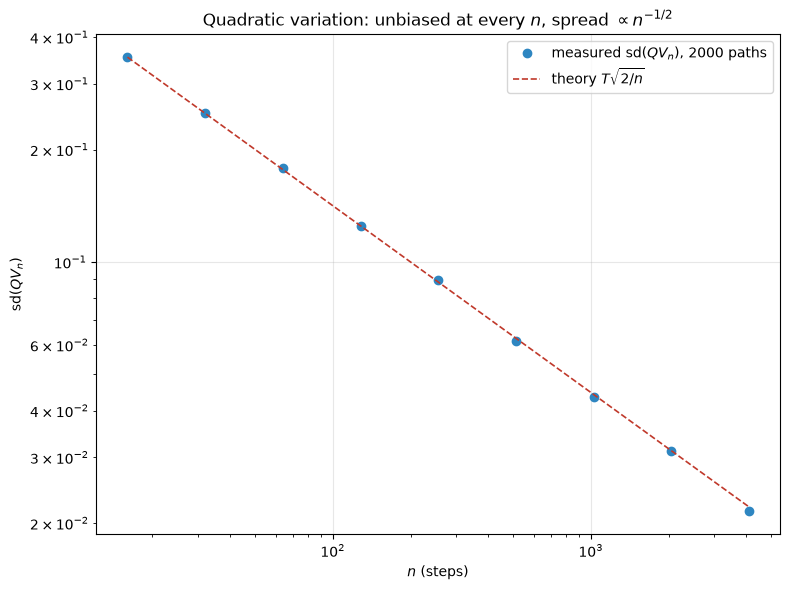

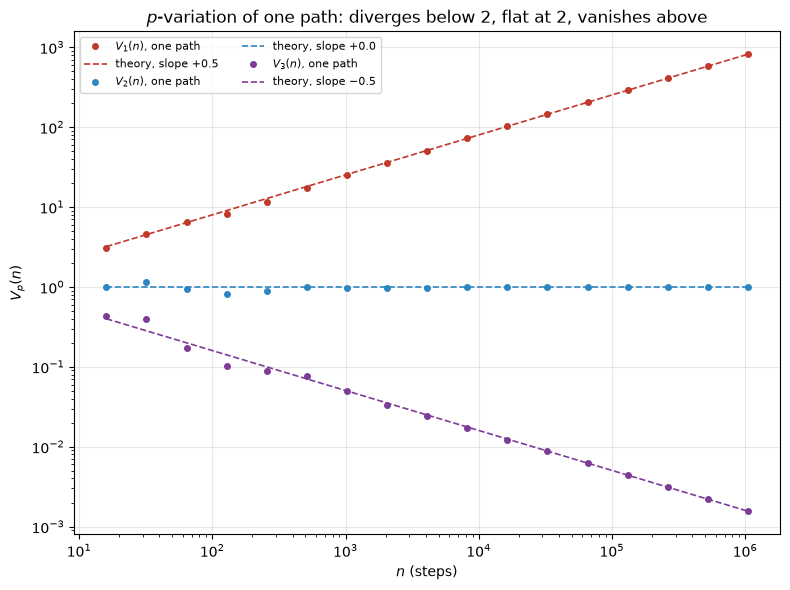

In [7]:
# Diagnostic 1: the spread of QV falls like n^{-1/2}
ns = 2 ** np.arange(4, 13)
sds = [
    variation.quadratic_variation(
        paths.brownian(n=int(n), T=T, m=2000, seed=SEED + 100 + i)
    ).std(ddof=1)
    for i, n in enumerate(ns)
]

fig, ax = plt.subplots(figsize=FIGSIZE_DIAG)
ax.loglog(ns, sds, "o", color=ACCENT, label="measured sd($QV_n$), 2000 paths")
ax.loglog(ns, T * np.sqrt(2 / ns), "--", color=ACCENT_ALT, label=r"theory $T\sqrt{2/n}$")
ax.set_xlabel("$n$ (steps)")
ax.set_ylabel("sd($QV_n$)")
ax.set_title("Quadratic variation: unbiased at every $n$, spread $\\propto n^{-1/2}$")
ax.legend()
fig.tight_layout()
plt.show()

# Diagnostic 2: the same path summed with three different exponents
ns_p = 2 ** np.arange(4, 21)
fig, ax = plt.subplots(figsize=FIGSIZE_DIAG)
for p, colour in zip((1.0, 2.0, 3.0), (ACCENT_ALT, ACCENT, "#7D3C98"), strict=True):
    measured = [float(variation.p_variation(W[:: N_FINE // int(n)], p)) for n in ns_p]
    mu_p = 2 ** (p / 2) * gamma((p + 1) / 2) / np.sqrt(np.pi)
    ax.loglog(ns_p, measured, "o", ms=4, color=colour, label=f"$V_{{{p:.0f}}}(n)$, one path")
    ax.loglog(ns_p, mu_p * T ** (p / 2) * ns_p ** (1.0 - p / 2), "--", color=colour,
              label=f"theory, slope ${1 - p / 2:+.1f}$")
ax.set_xlabel("$n$ (steps)")
ax.set_ylabel("$V_p(n)$")
ax.set_title("$p$-variation of one path: diverges below 2, flat at 2, vanishes above")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

**Result: Brownian motion has $p$-variation index 2, and $p = 2$ is the only exponent whose sum
converges to something finite and non-zero.** The first plot puts the measured spread of $QV_n$ on
$T\sqrt{2/n}$ over eight octaves: the $n^{-1/2}$ rate, with no fitted parameter. The second sums a
*single* path three ways: $p = 1$ climbs the predicted slope $+1/2$, $p = 2$ is flat at $T = 1$
across sixteen doublings, $p = 3$ falls away at $-1/2$. The dashed lines are
$\mu_p T^{p/2} n^{1-p/2}$ from step 4: theory, not a regression.

Hold that flat middle line: notebook 01 draws it again for $H = 0.1$, where it sits at $p = 10$.

### Feel it move

One slider for the grid, one for the seed. Watch the running quadratic variation $[W]_t$ against the
line $y = t$: coarse grids wander, fine grids hug it, no grid moves where it ends up.

*The widget needs a running kernel. On GitHub it is an empty box, and the next cell draws it
statically.*

In [8]:
def running_qv_view(log2n: int, seed: int) -> None:
    """Draw one path and its running quadratic variation on a grid of 2**log2n steps."""
    n = 2**log2n
    w = paths.brownian(n=n, T=T, m=1, seed=seed)[0]
    grid = np.linspace(0.0, T, n + 1)

    fig, (ax_path, ax_qv) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
    ax_path.plot(grid, w, color=ACCENT, alpha=0.8)
    ax_path.set_title(f"path, $n = {n}$ steps (seed {seed})")
    ax_path.set_xlabel("$t$")
    ax_path.set_ylabel("$W_t$")

    qv_t = variation.quadratic_variation(w, running=True)
    ax_qv.plot(grid[1:], qv_t, color=ACCENT, alpha=0.8, label=r"running $[W]_t$")
    ax_qv.plot(grid, grid, "--", color=ACCENT_ALT, label="$y = t$")
    ax_qv.set_title(f"realised $[W]_T$ = {qv_t[-1]:.3f}   vs   $T$ = {T:.3f}")
    ax_qv.set_xlabel("$t$")
    ax_qv.set_ylabel(r"$[W]_t$")
    ax_qv.legend()
    fig.tight_layout()
    plt.show()


_ = widgets.interact(
    running_qv_view,
    log2n=widgets.IntSlider(min=4, max=12, value=8, description="log2 n"),
    seed=widgets.IntSlider(min=0, max=9, value=0, description="seed"),
)

interactive(children=(IntSlider(value=8, description='log2 n', max=12, min=4), IntSlider(value=0, description=…

The static version: three panels, three grids. The slider draws an
independent path each time; here all three read the *same* path at $n = 2^6$, $2^9$ and $2^{12}$, so
only the sampling frequency changes.

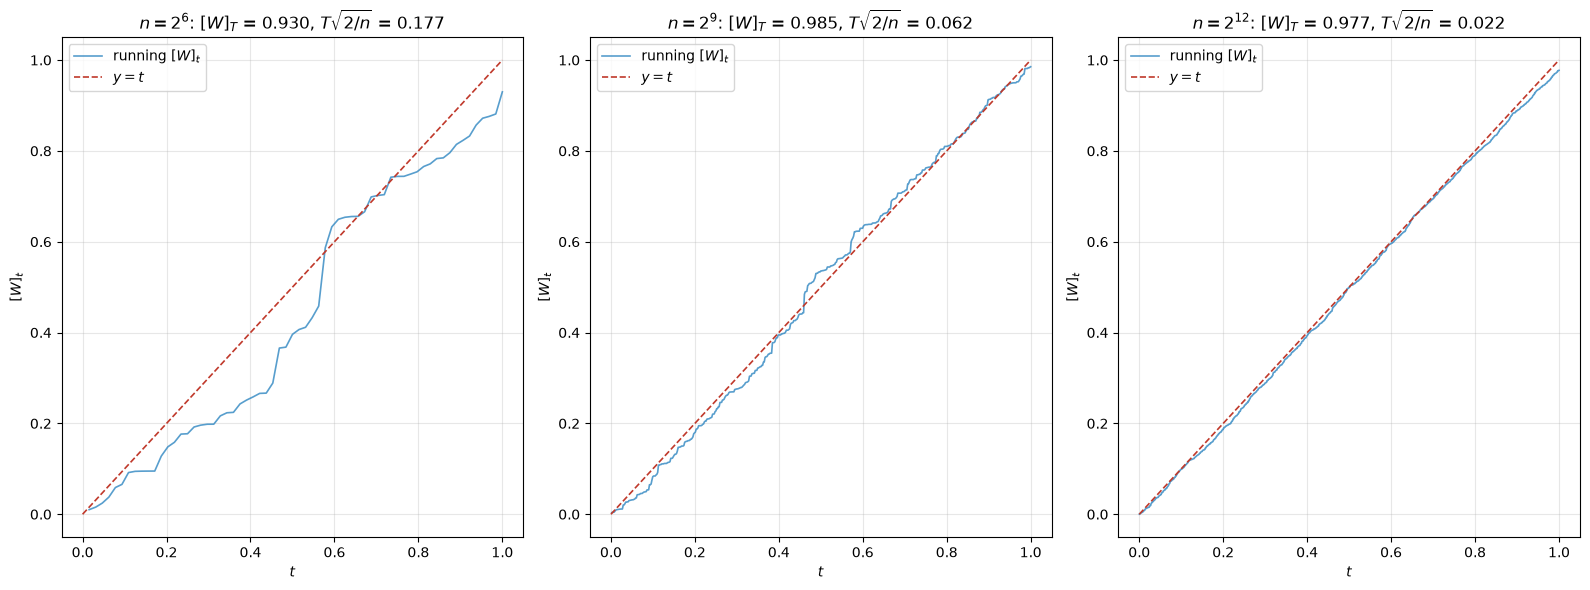

In [9]:
# Static fallback: one path, three grids, nested so it is literally the same path read more finely
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
for ax, k in zip(axes, (6, 9, 12), strict=True):
    n = 2**k
    sub = W[:: N_FINE // n]
    grid = np.linspace(0.0, T, n + 1)
    qv_t = variation.quadratic_variation(sub, running=True)
    ax.plot(grid[1:], qv_t, color=ACCENT, alpha=0.8, label=r"running $[W]_t$")
    ax.plot(grid, grid, "--", color=ACCENT_ALT, label="$y = t$")
    band = T * np.sqrt(2 / n)
    ax.set_title(f"$n = 2^{{{k}}}$: $[W]_T$ = {qv_t[-1]:.3f}, $T\\sqrt{{2/n}}$ = {band:.3f}")
    ax.set_xlabel("$t$")
    ax.set_ylabel(r"$[W]_t$")
    ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**Result: refining the grid changes how tightly the running $[W]_t$ tracks $t$, not where it goes.**
At $n = 2^6$ the realised variance strays from the diagonal and lands at $0.930$, against a band
$T\sqrt{2/n} = 0.177$. At $n = 2^{12}$ it lands at $0.977$ against a band of $0.022$ and tracks the
line the whole way. Neither miss is remarkable: the band itself shrank eightfold.

### Whiteboard checkpoint

Close the notebook and answer these aloud. If an answer needs the screen, the section has not landed
yet.

**(i)** Why is $\mathbb{E}[QV_n] = T$ for *every* $n$, and what is it that actually converges as
$n \to \infty$?

<details>
<summary>Worked answer</summary>

Write $\Delta W_i = \sqrt{\Delta t}\,Z_i$ with $Z_i$ iid standard normal and $\Delta t = T/n$. Then
$QV_n = \Delta t \sum_{i=1}^n Z_i^2$, so

$$\mathbb{E}[QV_n] = \Delta t \cdot n \cdot \mathbb{E}[Z^2] = n \cdot \frac{T}{n} \cdot 1 = T .$$

Every $n$, exactly: an algebraic identity, not a limit, and it uses only $\mathbb{E}[Z^2] = 1$, not
independence.

What converges is the random variable $QV_n$ itself. Independence gives
$\operatorname{Var}(QV_n) = n (\Delta t)^2 \operatorname{Var}(Z^2) = 2T^2/n \to 0$, using
$\operatorname{Var}(Z^2) = \mathbb{E}[Z^4] - 1 = 2$. So the spread around $T$ shrinks like
$n^{-1/2}$ and $QV_n \to T$ in mean square. A typical miss gets smaller, but not on every
refinement: the table has $n = 16$ closer than $n = 32$. The trap is to say "$QV_n$ converges to
$T$ as the mesh goes to zero" and hide that there was no bias to shrink.

</details>

**(ii)** $\sum_i |\Delta W_i| \to \infty$ while $\sum_i (\Delta W_i)^2 \to t$. What does that pair of
facts say about the Hölder exponent of the path, and what changes at $H = 0.1$?

<details>
<summary>Worked answer</summary>

Start from the counting argument of step 4. Increments of size $(\Delta t)^H$ make a sum of $n$
$p$-th powers scale like $n \cdot (T/n)^{pH} = T^{pH}\,n^{1 - pH}$: it vanishes when $pH > 1$,
blows up when $pH < 1$, and only $p = 1/H$ sits in between.

Read the pair of facts with that. For Brownian motion $p = 2$ stays finite, so $pH = 1$ and
$H = 1/2$; $p = 1$ blows up, which is the absolute column running away. Pathwise the same scaling
makes $|W_t - W_s| \le C|t-s|^{\gamma}$ hold for every $\gamma < 1/2$ and fail at $\gamma = 1/2$, so
there is no derivative anywhere.

At $H = 0.1$ increments scale as $(\Delta t)^{0.1}$, so the squared sum grows like
$n^{1 - 2H} = n^{0.8}$: **the quadratic variation is infinite**. You need $p = 10$ before the sums
stop growing, so the index is $1/H = 10$ and the Hölder exponent is $0.1$. The picture: zoom in by
$1000$ and the wiggles only halve, because $1000^{0.1} \approx 2$, where Brownian motion shrinks
them by about $32$.

Such a process is not a semimartingale: no Itô calculus, and no $\tfrac{1}{2}f''\,d[X]$ term to
write down. Which is why rough volatility puts $H \approx 0.1$ on
the *volatility* and leaves the price at $H = 1/2$.

</details>

**(iii)** Start from Itô's formula and derive the delta-hedged P&L identity of the hook. At which
step does quadratic variation enter, and why is the P&L nevertheless *not* a function of $[S]_T$
alone?

<details>
<summary>Worked answer</summary>

Itô on $f(t, S_t)$, priced at $\sigma_{\text{imp}}$, gives
$df = \theta_t\,dt + \Delta_t\,dS + \tfrac{1}{2}\Gamma_t\,d[S]$. Holding $-\Delta_t$ shares removes
$\Delta_t\,dS$. The Black–Scholes PDE at $\sigma_{\text{imp}}$ and $r = 0$ fixes the first survivor,
$\theta_t = -\tfrac{1}{2}\sigma_{\text{imp}}^2 S_t^2 \Gamma_t$. The second is
$\tfrac{1}{2}\Gamma_t\,d[S] = \tfrac{1}{2}\Gamma_t S_t^2 \sigma_{\text{real},t}^2\,dt$: that is
where quadratic variation enters. Adding them leaves

$$\tfrac{1}{2}\Gamma_t S_t^2\left(\sigma_{\text{real},t}^2 - \sigma_{\text{imp}}^2\right) dt ,$$

realised variance against implied, gamma-weighted, the implied leg arriving from theta.

It is not a function of $[S]_T$ because of the weight. The integrand carries the dollar gamma
$\Gamma_t S_t^2$, which changes along the path, large near the strike close to expiry and small
far from it. So two paths with the same total $[S]_T$ that spend their variance in different
places pay the hedger different amounts. Hold the dollar gamma constant and the dependence
collapses to $[\log S]_T$, theta leg and all. That instrument is the log contract, which is why a
variance swap's payoff *is* a function of $[\log S]_T$ alone.

</details>

## 2. The Itô isometry: the variance of a stochastic integral

Section 1 ended with a delta-hedged P&L. The hedge that produced it, $\int_0^T \Delta_t\,dS_t$, is an
integral against the moves themselves: a weight, fixed before the market moves, times the move,
added up. Almost every risk number in this series has that shape, $\int_0^T f_s\,dW_s$.

Risk asks one question of it. **How big is it?** The answer is the Itô isometry. This section proves
it, shows the assumption it leans on, then shows what it costs when the weight blows up — the
case rough volatility lands in.

### The intuition: independent kicks add their variances

Chop $[0, T]$ into $n$ steps. Over each step Brownian motion delivers one kick. The kicks are
independent, each with standard deviation $\sqrt{\Delta t}$. You pick a weight for each kick
*before* it lands, then add up weight times kick.

Independent things add their variances. A kick weighted by $f_i$ puts $f_i^2\,\Delta t$ into the
variance of the total, and nothing else goes in, because different kicks are uncorrelated. So the
total variance is $\sum_i f_i^2\,\Delta t$, a Riemann sum for $\int_0^T f_s^2\,ds$.

**The variance of a stochastic integral is an ordinary integral of the squared weights.**

One condition carries all of it: each weight is chosen before the kick it multiplies. The derivation
uses that twice, and the next experiment prices breaking it.

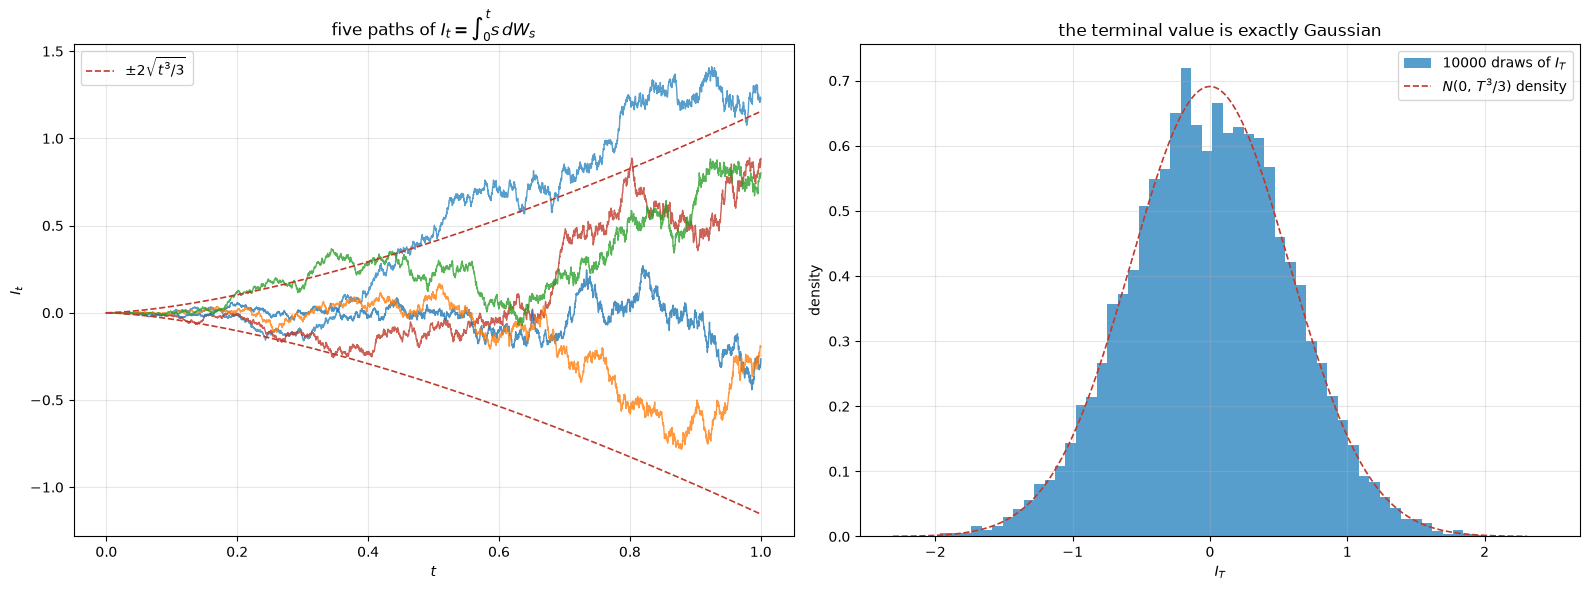

sample sd of I_T : 0.58261     theory sqrt(T^3/3) = 0.57735
  relative error : +0.911%     4*SE band = 2.83%


In [10]:
N_TOY, M_TOY = 4096, 10000     # steps, and paths for the terminal histogram

# The simplest non-constant weight: f(s) = s. Isometry says Var(I_t) = int_0^t s^2 ds = t^3/3.
grid_toy = np.linspace(0.0, T, N_TOY + 1)
sd_toy = np.sqrt(grid_toy**3 / 3)

I_paths = paths.wiener_integral(lambda s: s, n=N_TOY, T=T, m=5, seed=SEED + 10)
I_end = paths.wiener_integral(lambda s: s, n=N_TOY, T=T, m=M_TOY, seed=SEED + 11)[:, -1]

fig, (ax_p, ax_h) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
for row in I_paths:
    ax_p.plot(grid_toy, row, alpha=0.8, lw=1.0)
ax_p.plot(grid_toy, 2 * sd_toy, "--", color=ACCENT_ALT, label=r"$\pm 2\sqrt{t^3/3}$")
ax_p.plot(grid_toy, -2 * sd_toy, "--", color=ACCENT_ALT)
ax_p.set_title(r"five paths of $I_t = \int_0^t s\, dW_s$")
ax_p.set_xlabel("$t$")
ax_p.set_ylabel("$I_t$")
ax_p.legend(loc="upper left")

sd_T = np.sqrt(T**3 / 3)
xs = np.linspace(-4 * sd_T, 4 * sd_T, 400)
ax_h.hist(I_end, bins=60, density=True, color=ACCENT, alpha=0.8, label=f"{M_TOY} draws of $I_T$")
ax_h.plot(xs, np.exp(-(xs**2) / (2 * sd_T**2)) / (sd_T * np.sqrt(2 * np.pi)),
          "--", color=ACCENT_ALT, label=r"$N(0,\, T^3/3)$ density")
ax_h.set_title("the terminal value is exactly Gaussian")
ax_h.set_xlabel("$I_T$")
ax_h.set_ylabel("density")
ax_h.legend()
fig.tight_layout()
plt.show()

# Exactly Gaussian draws, so the relative SE of a sample sd is exactly 1 / sqrt(2 * (m - 1)).
band_toy = 4 / np.sqrt(2 * (M_TOY - 1))
print(f"sample sd of I_T : {I_end.std(ddof=1):.5f}     theory sqrt(T^3/3) = {sd_T:.5f}")
print(f"  relative error : {I_end.std(ddof=1) / sd_T - 1:+.3%}     4*SE band = {band_toy:.2%}")

**Result: the spread at time $t$ is the area under $f^2$ up to $t$, and the terminal value is exactly
Gaussian, not approximately.** The paths fan out slowly where the weight $f(s) = s$ is small, then faster. The dashed envelope is $\pm 2\sqrt{t^3/3}$, from the isometry with nothing
fitted, and the histogram sits on the normal density.

### Why: the isometry for a step integrand

Bookwork in full. **Nothing here needs a citation.** Grid $t_i = i\,\Delta t$, $\Delta t = T/n$,
increments $\Delta W_i = W_{t_i} - W_{t_{i-1}}$.

**1. The integrand.** Let $f$ be constant on each step, equal to $f_i$ on $(t_{i-1}, t_i]$. The
integral is a weighted sum of increments, in code `np.cumsum(weights * increments)`:

$$I \;=\; \sum_{i=1}^n f_i\, \Delta W_i .$$

The rule on $f_i$: it may depend on anything known by $t_{i-1}$, nothing after. That is what
*adapted* means, and it is the only structural assumption in the proof.

**2. Square it.** The variance is $\mathbb{E}[I^2]$, since $\mathbb{E}[I] = 0$. Expand into pairs,

$$\mathbb{E}[I^2] \;=\; \sum_{i=1}^n \sum_{j=1}^n \mathbb{E}\big[f_i f_j\, \Delta W_i \Delta W_j\big] .$$

**3. Every off-diagonal term is zero.** Take $i < j$. Three of the four factors, $f_i$, $f_j$ and
$\Delta W_i$, are known by time $t_{j-1}$. The fourth is independent of everything known by then and
has mean zero. So the expectation splits,

$$\mathbb{E}\big[f_i f_j \Delta W_i \cdot \Delta W_j\big] \;=\;
\mathbb{E}\big[f_i f_j \Delta W_i\big]\,\mathbb{E}\big[\Delta W_j\big] \;=\; 0 .$$

**4. The diagonal.** Here $f_i^2$ is known before $\Delta W_i$ arrives, so the same split works,
with $\operatorname{Var}(\Delta W_i) = \Delta t$ from section 1:

$$\mathbb{E}\big[f_i^2\, \Delta W_i^2\big] \;=\; \mathbb{E}[f_i^2]\; \mathbb{E}[\Delta W_i^2]
\;=\; \mathbb{E}[f_i^2]\, \Delta t .$$

**5. Add up.** Only the diagonal survives, so

$$\mathbb{E}[I^2] \;=\; \sum_{i=1}^n \mathbb{E}[f_i^2]\,\Delta t
\;=\; \mathbb{E}\!\int_0^T f_s^2\, ds ,$$

because $\sum_i f_i^2 \Delta t$ *is* the integral of the step function $f^2$. That is the **Itô
isometry**. Any $f \in L^2$ is a limit of step functions and the map $f \mapsto I$ preserves length,
so the identity survives the limit. *Stated, not proved: that completion.* For **deterministic** $f$
the expectations drop away:

$$\mathbb{E}\!\left[\int_0^T f_s\,dW_s\right] = 0, \qquad
\operatorname{Var}\!\left(\int_0^T f_s\,dW_s\right) = \int_0^T f_s^2\,ds ,$$

and the integral is exactly Gaussian, being fixed numbers times independent normals.

**6. What look-ahead would buy.** Steps 3 and 4 both used "the weight is fixed before the increment".
Break it: evaluate the integrand of $\int W\,dW$ a fraction $\theta$ into each step,

$$S_\theta \;=\; \sum_i \big[(1-\theta) W_{t_{i-1}} + \theta W_{t_i}\big]\, \Delta W_i .$$

Substituting $\Delta W_i^2 = W_{t_i}^2 - W_{t_{i-1}}^2 - 2 W_{t_{i-1}} \Delta W_i$ and summing gives
an exact identity, for every path and grid,

$$S_\theta \;=\; \tfrac{1}{2}\big(W_T^2 - W_0^2\big) \;+\; \big(\theta - \tfrac{1}{2}\big)\, QV_n .$$

Both $\mathbb{E}[W_T^2]$ and $\mathbb{E}[QV_n]$ equal $T$, so $\mathbb{E}[S_\theta] = \theta T$:
peeking is worth $\theta T$ of drift, made of section 1's quadratic variation.

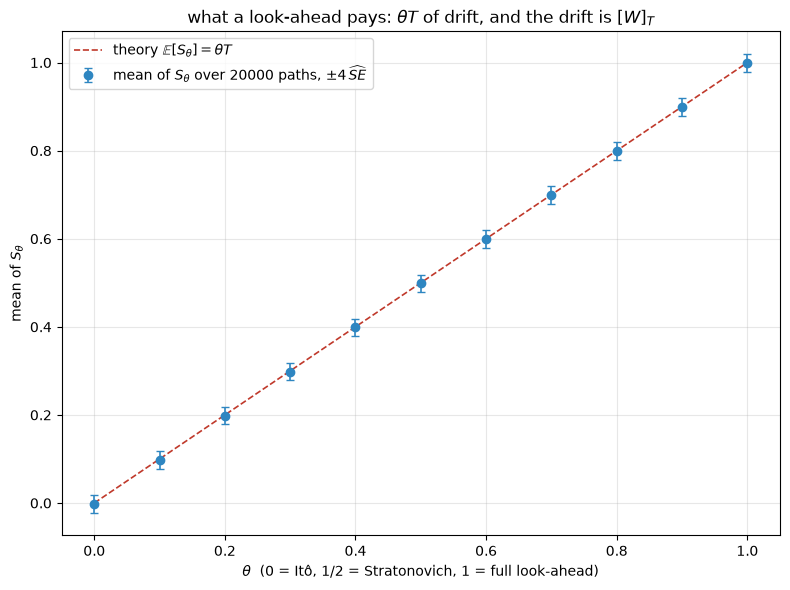

theta = 0.0 : mean -0.0015   theory +0.0000   deviation / 4*SE = 0.07   (pass if < 1)
theta = 0.5 : mean +0.4986   theory +0.5000   deviation / 4*SE = 0.07   (pass if < 1)


theta = 1.0 : mean +0.9986   theory +1.0000   deviation / 4*SE = 0.07   (pass if < 1)


In [11]:
N_TH, M_TH = 512, 20000
W_th = paths.brownian(n=N_TH, T=T, m=M_TH, seed=SEED + 2)

thetas = np.linspace(0.0, 1.0, 11)
sums = [variation.theta_sum(W_th, float(th)) for th in thetas]
means = np.array([s.mean() for s in sums])
ses = np.array([s.std(ddof=1) / np.sqrt(M_TH) for s in sums])   # CLT error on the mean

fig, ax = plt.subplots(figsize=FIGSIZE_DIAG)
ax.errorbar(thetas, means, yerr=4 * ses, fmt="o", color=ACCENT, capsize=3,
            label=r"mean of $S_\theta$ over 20000 paths, $\pm 4\,\widehat{SE}$")
ax.plot(thetas, thetas * T, "--", color=ACCENT_ALT,
        label=r"theory $\mathbb{E}[S_\theta] = \theta T$")
ax.set_xlabel(r"$\theta$  (0 = Itô, 1/2 = Stratonovich, 1 = full look-ahead)")
ax.set_ylabel(r"mean of $S_\theta$")
ax.set_title(r"what a look-ahead pays: $\theta T$ of drift, and the drift is $[W]_T$")
ax.legend()
fig.tight_layout()
plt.show()

for th in (0.0, 0.5, 1.0):
    s = variation.theta_sum(W_th, th)
    se = s.std(ddof=1) / np.sqrt(M_TH)
    print(f"theta = {th:.1f} : mean {s.mean():+.4f}   theory {th * T:+.4f}   "
          f"deviation / 4*SE = {abs(s.mean() - th * T) / (4 * se):.2f}   (pass if < 1)")

**Result: look-ahead pays exactly $\theta T$, and the money is section 1's quadratic variation.** The
means sit on the line $y = \theta T$, each inside its Monte Carlo band. At $\theta = 0$ the sum is
centred at zero. At $\theta = 1$, where the weight sees the increment it multiplies, the same paths
collect $T$ of drift out of nothing, and refining the grid does not shrink that.

Three things break together: the isometry, the martingale property and no arbitrage all need
$\theta = 0$. That is why the Itô integral is the left-point one, and why *adapted* is a modelling
assumption rather than a technicality.

In [12]:
print(inspect.getsource(variation.theta_sum))

def theta_sum(path: np.ndarray, theta: float = 0.0) -> np.ndarray:
    """Sum of X dX evaluated at a theta-interpolated point in each step.

    For a path sampled at t_0 < ... < t_n,

        S_theta = sum_i [(1 - theta) X_{t_{i-1}} + theta X_{t_i}] * dX_i,
        dX_i = X_{t_i} - X_{t_{i-1}}.

    theta = 0 is the Ito sum (the integrand is fixed before the increment
    arrives), theta = 1/2 the Stratonovich sum, theta = 1 the look-ahead sum
    the isometry proof forbids. Telescoping dX_i**2 gives the exact identity,
    for every path and every grid,

        S_theta = (X_T**2 - X_0**2) / 2 + (theta - 1/2) * QV_n,

    with QV_n the realised quadratic variation. For Brownian motion started at
    0, E[QV_n] = T, so E[S_theta] = theta * T: only theta = 0 is centred, and
    only theta = 0 is a martingale. The free drift a look-ahead earns is
    exactly theta times the quadratic variation of section 1.

    Parameters
    ----------
    path : numpy.ndarray
        Sampled path(s);

Three lines of numpy. `dX` and `left` are the increments and the left end of every step, along the
**last** axis, so one path and a stack both work. Then
`weighted = (1 - theta) * left + theta * (left + dX)` is the interpolated point: note the `+ dX`, so
at $\theta > 0$ the weight contains the increment it multiplies. Look-ahead, in code.

The identity $S_\theta = \tfrac{1}{2}(X_T^2 - X_0^2) + (\theta - \tfrac{1}{2})QV_n$ is algebra, not
a limit: it holds path by path, on any grid. A test checks it on both $W$ and $W + 3$, which is why
the $X_0$ term is there: the measured error is $1.8\times 10^{-15}$ against an asserted $10^{-10}$.

In [13]:
print(inspect.getsource(paths.wiener_integral))

def wiener_integral(
    f: Callable[[np.ndarray], np.ndarray], n: int, T: float, m: int, seed: int
) -> np.ndarray:
    """Left-point approximation of the Wiener integral of a deterministic f.

    On the grid t_i = i * T / n, i = 0..n, with dt = T / n,

        I_{t_k} = sum_{i=0}^{k-1} f(t_i) * (W_{t_{i+1}} - W_{t_i}),

    the integrand evaluated at the LEFT end of each step and never at the
    right. For deterministic f the Ito isometry gives

        E[I_t] = 0,    Var(I_t) = integral_0^t f(s)**2 ds,

    and I_t is exactly Gaussian, being a fixed linear combination of
    independent normals. The discrete sum has variance dt * sum_i f(t_i)**2,
    a Riemann sum for that integral which equals it only in the limit; see
    `power_kernel_weights` for a kernel where the gap closes very slowly.

    Increments are drawn exactly as in `brownian`: one call to
    rng.standard_normal((m, n)) scaled by sqrt(dt), rng = default_rng(seed),
    so one seed means the same underlying path in 

The simulator is the derivation with the randomness put back.

- `weights = np.asarray(f(grid[:-1]))` evaluates $f$ on $t_0, \dots, t_{n-1}$: **left points only**.
  Here $f$ is deterministic, so right points would still give a centred Gaussian; only the Riemann
  sum for $\int f^2$ changes. The slice becomes the adaptedness condition as soon as the weight is
  built from $W$ itself, which is what the $\theta$ experiment above showed.
- `increments = np.sqrt(dt) * rng.standard_normal((m, n))` is the same draw as `brownian`, same
  shape, same seed, so the two compare path by path, not only in distribution. The `np.cumsum`
  returns the running integral in section 1's `(m, n + 1)` shape, so `[:, -1]` is the value at $T$.

Its variance is $\Delta t \sum_i f(t_i)^2$: a Riemann sum for $\int_0^T f^2\,ds$, not the integral
itself. For a well-behaved $f$ nobody notices. The rest of the section is about when you do.

### The kernel this series actually needs

Take the weight to be the distance to the endpoint, raised to a power:

$$f(s) \;=\; (t - s)^a , \qquad I_t \;=\; \int_0^t (t-s)^a\, dW_s .$$

In words: a kick is weighted by how long ago it happened. With $a < 0$ recent kicks count for much
more than old ones, and the weight on the last instant is infinite: a sharp memory of the recent
past and almost none of the distant past.

The isometry gives the variance at once, substituting $u = t - s$:

$$\operatorname{Var}(I_t) \;=\; \int_0^t (t-s)^{2a}\, ds \;=\; \int_0^t u^{2a}\, du
\;=\; \frac{t^{2a+1}}{2a+1} , \qquad a > -\tfrac{1}{2} .$$

Where the condition comes from: near $u = 0$, which is $s = t$, the integrand blows up when $a < 0$,
and $\int_0 u^{2a}\,du$ is finite exactly when $2a + 1 > 0$. At $a = -1/2$ the variance is infinite
and there is no such process.

One forward reference and no more. With $a = H - \tfrac{1}{2}$ and a prefactor $\sqrt{2H}$ the
variance becomes $t^{2H}$, that of fractional Brownian motion: the **Riemann–Liouville process**
of notebook 01.

In [14]:
N_ISO, M_ISO = 512, 10000

# A Wiener integral of a deterministic integrand is EXACTLY Gaussian, so the sample variance of m
# draws has an exact relative standard error sqrt(2 / (m - 1)). No CLT approximation is needed.
band = 4 * np.sqrt(2 / (M_ISO - 1))

print(f"{'a':>6} {'sample var':>12} {'closed form':>12} {'rel error':>11} {'4*SE band':>11}")
for a in (0.0, 0.3):
    draws = paths.power_kernel_integral(a, N_ISO, T, M_ISO, seed=SEED + 3, exact=False)
    s2 = draws.var(ddof=1)
    target = T ** (2 * a + 1) / (2 * a + 1)
    print(f"{a:6.1f} {s2:12.5f} {target:12.5f} {s2 / target - 1:+11.3%} {band:11.2%}")

     a   sample var  closed form   rel error   4*SE band
   0.0      0.99932      1.00000     -0.068%       5.66%
   0.3      0.62604      0.62500     +0.166%       5.66%


**Result: for a well-behaved kernel the naive sum matches the closed form to within Monte Carlo
error.** Both rows land a small fraction of the band from the closed form, on the crude
left-point rule with 512 steps.

### The trap: a left-point sum on a singular kernel

Now set $a = -0.4$. The kernel is finite everywhere except at $s = t$, where it goes to infinity.
The variance integral still converges, since $2a + 1 = 0.2 > 0$, so the process exists.

The left-point rule does not cope. On the last step the left end is where the kernel is *smallest*,
and across that step it climbs to infinity. Holding that value fixed throws away most of what the
step contributes.

So the discrete variance $\Delta t \sum_{i=0}^{n-1} (t - t_i)^{2a}$ falls short of
$t^{2a+1}/(2a+1)$. That is a **bias**, not noise: a number fixed by the grid, which no amount of
averaging removes.

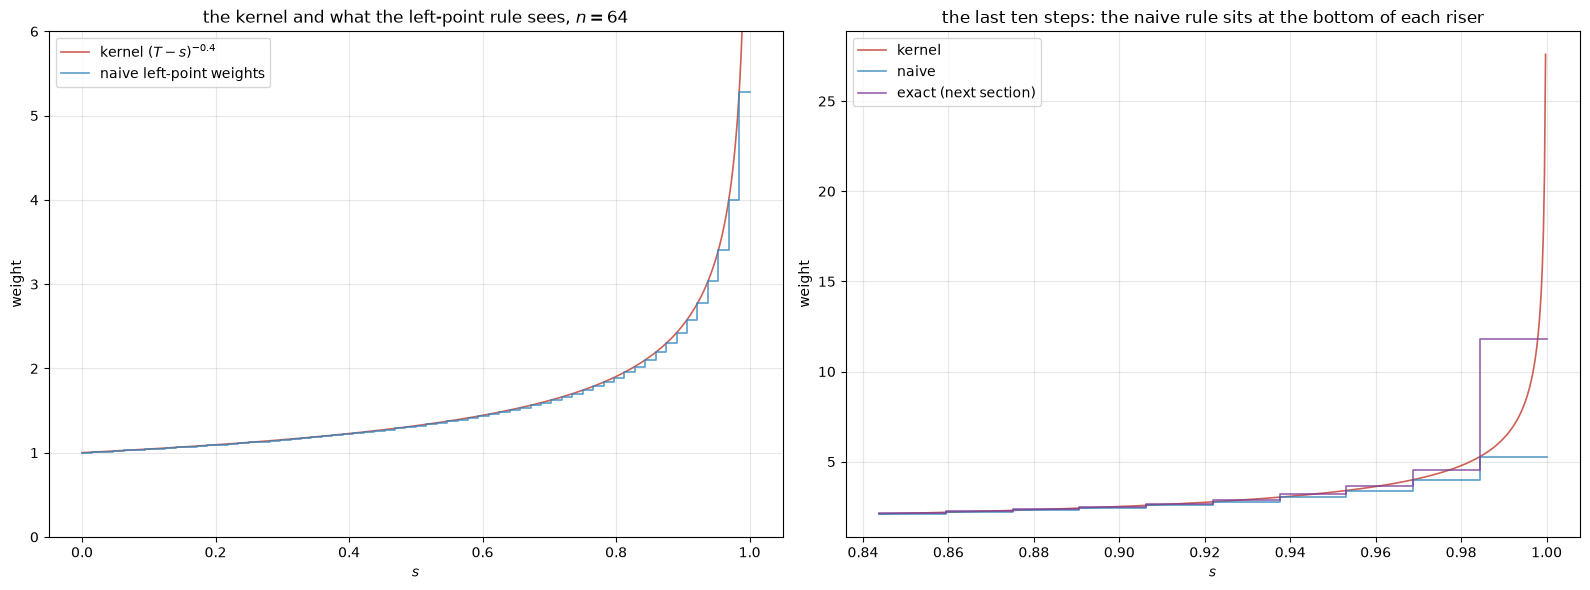

last step, naive weight : 5.2780   = dt**a
last step, exact weight : 11.8020
ratio                   : 2.2361   theory 1/sqrt(2a+1) = 2.2361


In [15]:
A_SING, N_PIC = -0.4, 64
dt_pic = T / N_PIC
left_pic = np.linspace(0.0, T, N_PIC + 1)[:-1]
w_naive_pic = paths.power_kernel_weights(A_SING, N_PIC, T, exact=False)
w_exact_pic = paths.power_kernel_weights(A_SING, N_PIC, T, exact=True)

fine = np.linspace(0.0, T, 4001)[:-1]          # stop short of s = T, where the kernel is infinite

fig, (ax_k, ax_z) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
ax_k.plot(fine, (T - fine) ** A_SING, color=ACCENT_ALT, alpha=0.8,
          label=f"kernel $(T-s)^{{{A_SING}}}$")
ax_k.step(np.append(left_pic, T), np.append(w_naive_pic, w_naive_pic[-1]), where="post",
          color=ACCENT, alpha=0.8, label="naive left-point weights")
ax_k.set_ylim(0, 6)
ax_k.set_title(f"the kernel and what the left-point rule sees, $n = {N_PIC}$")
ax_k.set_xlabel("$s$")
ax_k.set_ylabel("weight")
ax_k.legend(loc="upper left")

tail = slice(N_PIC - 10, N_PIC)
ax_z.plot(fine[fine >= left_pic[N_PIC - 10]], (T - fine[fine >= left_pic[N_PIC - 10]]) ** A_SING,
          color=ACCENT_ALT, alpha=0.8, label="kernel")
ax_z.step(np.append(left_pic[tail], T), np.append(w_naive_pic[tail], w_naive_pic[-1]), where="post",
          color=ACCENT, alpha=0.8, label="naive")
ax_z.step(np.append(left_pic[tail], T), np.append(w_exact_pic[tail], w_exact_pic[-1]), where="post",
          color="#7D3C98", alpha=0.8, label="exact (next section)")
ax_z.set_title("the last ten steps: the naive rule sits at the bottom of each riser")
ax_z.set_xlabel("$s$")
ax_z.set_ylabel("weight")
ax_z.legend(loc="upper left")
fig.tight_layout()
plt.show()

print(f"last step, naive weight : {w_naive_pic[-1]:.4f}   = dt**a")
print(f"last step, exact weight : {w_exact_pic[-1]:.4f}")
print(f"ratio                   : {w_exact_pic[-1] / w_naive_pic[-1]:.4f}"
      f"   theory 1/sqrt(2a+1) = {1 / np.sqrt(2 * A_SING + 1):.4f}")

**Result: on the last step the naive weight is too small by a factor of $1/\sqrt{2a+1} = 2.24$.** The
zoom shows why: the kernel runs up the right-hand edge of every step and the staircase sits at the
bottom of each riser. Away from the end the mismatch is mild; on the final step it is not, and
that step carries most of the missing variance.

### The fix: give each step its own exact variance

Stop pretending the kernel is flat across a step. Ask what the true integral over it does.

Over step $i$ the contribution is $\int_{t_i}^{t_{i+1}} (t-s)^a\,dW_s$: Gaussian, mean zero, and by
the isometry its variance is

$$v_i \;=\; \int_{t_i}^{t_{i+1}} (t-s)^{2a}\,ds
\;=\; \frac{(t - t_i)^{2a+1} - (t - t_{i+1})^{2a+1}}{2a+1} .$$

Different steps use disjoint pieces of $W$, so they are independent and their variances add. The sum
$\sum_i v_i$ **telescopes**: the interior terms cancel, leaving $t^{2a+1}/(2a+1)$ exactly at every
$n$, not in a limit.

Turn each $v_i$ into a weight on a standard increment,

$$w_i \;=\; \sqrt{v_i / \Delta t} , \qquad I \;=\; \sum_i w_i\, \Delta W_i ,$$

so $\operatorname{Var}(I) = \Delta t \sum_i w_i^2 = \sum_i v_i$, the closed form to machine
precision. The weight is a root-mean-square of the kernel over the step, not its left value. This
block is the seed of notebook 04's **hybrid scheme**.

One caveat, stated once. These weights reproduce the *law of the integral* exactly, but not its
*joint law with $W$*: here $\operatorname{Cov}(w_i \Delta W_i, \Delta W_i) = w_i\Delta t$, where the
true step integral has $\int (t-s)^a ds$. That repair is notebook 04's job, and everything below is
a variance, so it does not bite yet.

In [16]:
print(inspect.getsource(paths.power_kernel_weights))
print(inspect.getsource(paths.power_kernel_integral))

def power_kernel_weights(a: float, n: int, T: float, exact: bool = True) -> np.ndarray:
    """Step weights for the power kernel f(s) = (T - s)**a on [0, T].

    Two weightings of the same n steps, both used as
    I = sum_i w_i * (W_{t_{i+1}} - W_{t_i}).

    exact=False, the naive left-point rule:

        w_i = (T - t_i)**a,          dt * sum_i w_i**2 = a Riemann sum.

    exact=True, the root-mean-square weight reproducing the variance of the
    true integral over each step:

        v_i = ((T - t_i)**(2a + 1) - (T - t_{i+1})**(2a + 1)) / (2a + 1),
        w_i = sqrt(v_i / dt),        dt * sum_i w_i**2 = T**(2a + 1)/(2a + 1)

    exactly, because the v_i telescope. That closed form is the Ito isometry
    applied to (T - s)**a and needs 2a + 1 > 0.

    Why it matters: for a < 0 the kernel blows up at s = T, the left point is
    the smallest value it takes on the last step, and the naive sum loses
    variance at the rate n**(-(2a+1)) - at a = -0.4, n = 1024 it is still 22%
    

The branch is the interesting part.

- `if not exact: return (T - left) ** a` is the naive rule in one line.
- `v = ((T - left) ** (2a + 1) - (T - right) ** (2a + 1)) / (2a + 1)` is $v_i$ verbatim, and
  `np.sqrt(v / dt)` is $w_i$. The telescoping is nowhere in the code: it is a property of `v`,
  checked by a test whose measured error is $3\times 10^{-16}$ against an asserted $10^{-12}$.
- `power_kernel_integral` draws the same increments as `brownian`, so a naive and an exact run
  differ only in weighting. It returns the value at $T$ **only**, because $(T-s)^a$ is a different
  function for every endpoint. That is why the Riemann–Liouville process is rebuilt at every time
  point.

In [17]:
target_sing = T ** (2 * A_SING + 1) / (2 * A_SING + 1)

print(f"a = {A_SING}, n = {N_ISO}, m = {M_ISO}, same increments in both rows")
print(f"{'rule':>18} {'sample var':>12} {'closed form':>12} {'rel error':>11} {'4*SE band':>11}")
for label, exact in (("naive left-point", False), ("exact weights", True)):
    draws = paths.power_kernel_integral(A_SING, N_ISO, T, M_ISO, seed=SEED + 4, exact=exact)
    s2 = draws.var(ddof=1)
    print(f"{label:>18} {s2:12.5f} {target_sing:12.5f} {s2 / target_sing - 1:+11.2%} {band:11.2%}")

w = paths.power_kernel_weights(A_SING, N_ISO, T, exact=False)
deficit = (T / N_ISO) * np.sum(w**2) / target_sing - 1
print(f"\ndeterministic deficit of the naive rule at n = {N_ISO}: {deficit:+.2%}")

a = -0.4, n = 512, m = 10000, same increments in both rows
              rule   sample var  closed form   rel error   4*SE band
  naive left-point      3.65519      5.00000     -26.90%       5.66%
     exact weights      4.88853      5.00000      -2.23%       5.66%

deterministic deficit of the naive rule at n = 512: -25.47%


**Result: the naive sum is a quarter short, and it is not Monte Carlo error.** The same increments,
weighted exactly, land $2.2\%$ from the closed form, inside a band of $5.7\%$. Weighted by the
left-point rule they land $27\%$ short, nearly five bands away. The deficit underneath is $25.5\%$ before any
random number is drawn.

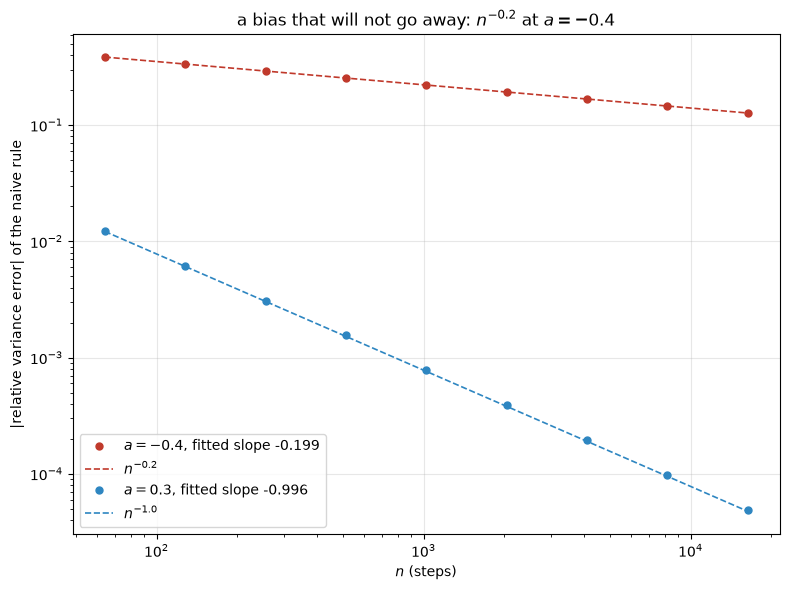

n =    256 : error at a = -0.4 is -29.24%,   at a = 0.3 it is +0.3087%
n =   1024 : error at a = -0.4 is -22.18%,   at a = 0.3 it is +0.0777%
n =   4096 : error at a = -0.4 is -16.81%,   at a = 0.3 it is +0.0195%
n =  16384 : error at a = -0.4 is -12.74%,   at a = 0.3 it is +0.0049%


In [18]:
def naive_rel_error(a: float, n: int) -> float:
    """Signed relative error of the naive left-point variance against the closed form.

    Negative for a < 0 (the singular end is under-weighted), positive for a > 0
    (a left-point rule on a falling kernel overshoots).
    """
    w = paths.power_kernel_weights(a, int(n), T, exact=False)
    return (T / n) * np.sum(w**2) / (T ** (2 * a + 1) / (2 * a + 1)) - 1.0


ns_bias = 2 ** np.arange(6, 15)
fig, ax = plt.subplots(figsize=FIGSIZE_DIAG)
for a, colour, ref in ((A_SING, ACCENT_ALT, 0.2), (0.3, ACCENT, 1.0)):
    dev = np.abs([naive_rel_error(a, int(n)) for n in ns_bias])
    slope = np.polyfit(np.log(ns_bias), np.log(dev), 1)[0]
    ax.loglog(ns_bias, dev, "o", ms=5, color=colour, label=f"$a = {a}$, fitted slope {slope:+.3f}")
    ax.loglog(ns_bias, dev[0] * (ns_bias / ns_bias[0]) ** (-ref), "--", color=colour,
              label=f"$n^{{-{ref}}}$")
ax.set_xlabel("$n$ (steps)")
ax.set_ylabel("|relative variance error| of the naive rule")
ax.set_title("a bias that will not go away: $n^{-0.2}$ at $a = -0.4$")
ax.legend()
fig.tight_layout()
plt.show()

for n in (256, 1024, 4096, 16384):
    print(f"n = {n:>6} : error at a = -0.4 is {naive_rel_error(A_SING, n):+7.2%},"
          f"   at a = 0.3 it is {naive_rel_error(0.3, n):+.4%}")

**Result: at $a = -0.4$ the naive rule still loses $22\%$ of the variance at $n \approx 1000$, and the
error falls only like $n^{-0.2}$.** The fitted slope is $-0.199$ against the predicted $-0.2$, over
nine doublings. At $a = 0.3$ the kernel is bounded and the error is the ordinary $n^{-1}$ of a
left-point Riemann sum, below $0.1\%$ at $n = 1024$.

The two signs differ. For $a > 0$ the kernel *falls* across each step, so the left point is too big
and the naive sum overshoots. For $a < 0$ it rises, and the last step's blow-up flips the sign.

Name it: **a slowly vanishing bias that no sane grid removes.** Sixteen times the work, $n = 1024$ to
$n = 16384$, takes the error from $22\%$ only to $13\%$. That is what notebook 04's hybrid
scheme is built to remove: it treats the steps at the singularity exactly and leaves the rest cheap.

### Feel it move

One slider for the exponent $a$, one for the grid. Watch the weightings separate as $a$ goes
negative.

*The widget needs a running kernel; on GitHub it is an empty box, and the next cell draws it
statically.*

In [19]:
def kernel_view(a: float, log2n: int) -> None:
    """Naive vs exact weights for (T - s)**a, and the variance each one delivers."""
    n, m = 2**log2n, 2000
    left = np.linspace(0.0, T, n + 1)[:-1]
    w_naive = paths.power_kernel_weights(a, n, T, exact=False)
    w_exact = paths.power_kernel_weights(a, n, T, exact=True)
    target = T ** (2 * a + 1) / (2 * a + 1)
    v_naive = paths.power_kernel_integral(a, n, T, m, seed=SEED + 5, exact=False).var(ddof=1)
    v_exact = paths.power_kernel_integral(a, n, T, m, seed=SEED + 5, exact=True).var(ddof=1)

    fig, (ax_w, ax_v) = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
    ax_w.step(left, w_naive, where="post", color=ACCENT, alpha=0.8, label="naive left-point")
    ax_w.step(left, w_exact, where="post", color="#7D3C98", alpha=0.8, label="exact")
    # The final weights run off the top for a < 0; clip so the body of the kernel stays visible.
    ax_w.set_ylim(0, max(3.0 * w_exact[n // 2], 1.2 * w_exact[0]))
    ax_w.set_title(f"step weights, $a = {a:.2f}$, $n = {n}$ (y-axis clipped)")
    ax_w.set_xlabel("$s$")
    ax_w.set_ylabel("weight")
    ax_w.legend(loc="upper left")

    ax_v.bar(["naive", "exact"], [v_naive, v_exact], color=[ACCENT, "#7D3C98"], alpha=0.8)
    ax_v.axhline(target, ls="--", color=ACCENT_ALT, label=f"closed form {target:.4f}")
    ax_v.set_title(f"sample variance of {m} draws:"
                   f"  naive {v_naive / target - 1:+.1%},  exact {v_exact / target - 1:+.1%}")
    ax_v.set_ylabel("variance")
    ax_v.legend()
    fig.tight_layout()
    plt.show()


_ = widgets.interact(
    kernel_view,
    a=widgets.FloatSlider(min=-0.45, max=1.0, step=0.05, value=-0.4, description="a"),
    log2n=widgets.IntSlider(min=4, max=12, value=8, description="log2 n"),
)

interactive(children=(FloatSlider(value=-0.4, description='a', max=1.0, min=-0.45, step=0.05), IntSlider(value…

The static version, Monte Carlo taken out: the variance each rule has accumulated by time
$t$, on one grid of $256$ steps.

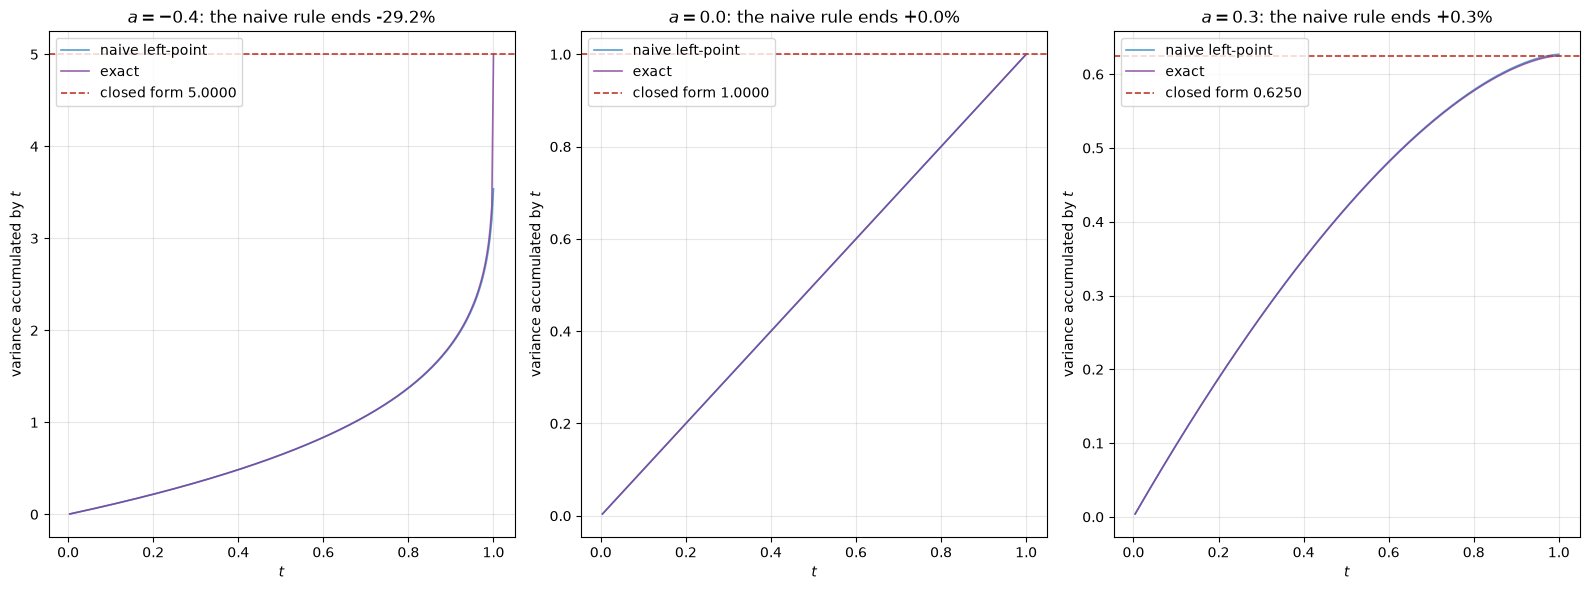

In [20]:
# Static fallback, deterministic: dt * cumsum(w**2) is the variance the rule has built up by time t.
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_WIDE)
for ax, a in zip(axes, (-0.4, 0.0, 0.3), strict=True):
    n = 256
    dt, grid = T / n, np.linspace(0.0, T, n + 1)
    target = T ** (2 * a + 1) / (2 * a + 1)
    w_naive = paths.power_kernel_weights(a, n, T, exact=False)
    w_exact = paths.power_kernel_weights(a, n, T, exact=True)
    ax.plot(grid[1:], dt * np.cumsum(w_naive**2), color=ACCENT, alpha=0.8,
            label="naive left-point")
    ax.plot(grid[1:], dt * np.cumsum(w_exact**2), color="#7D3C98", alpha=0.8, label="exact")
    ax.axhline(target, ls="--", color=ACCENT_ALT, label=f"closed form {target:.4f}")
    ax.set_title(f"$a = {a}$: the naive rule ends {dt * np.sum(w_naive**2) / target - 1:+.1%}")
    ax.set_xlabel("$t$")
    ax.set_ylabel("variance accumulated by $t$")
    ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**Result: the gap is a property of the kernel, not of the sampling.** At $a = 0$ the two rules are the same line and both land on the closed form. At
$a = 0.3$ they are indistinguishable. At $a = -0.4$ the exact curve reaches the line and the naive
one stops $29\%$ below it, most of the loss in the final steps. Roughness, not resolution, breaks
the naive rule.

### Whiteboard checkpoint

Close the notebook and answer aloud. If an answer needs the screen, the section has not landed.

**(i)** State the Itô isometry for a deterministic integrand and prove it for a step function.

<details>
<summary>Worked answer</summary>

For deterministic $f \in L^2[0,T]$, $\int_0^T f_s\,dW_s$ has mean zero and

$$\operatorname{Var}\!\left(\int_0^T f_s\,dW_s\right) \;=\; \int_0^T f_s^2\, ds .$$

Take $f$ constant $f_i$ on $(t_{i-1}, t_i]$, so $I = \sum_i f_i \Delta W_i$, and expand
$\mathbb{E}[I^2] = \sum_i \sum_j \mathbb{E}[f_i f_j \Delta W_i \Delta W_j]$. For $i < j$ the other
three factors are known by $t_{j-1}$ and $\Delta W_j$ is independent of them with mean zero, so that
term vanishes. On the diagonal $f_i^2$ is known before $\Delta W_i$ arrives, so it splits into
$\mathbb{E}[f_i^2]\Delta t$. Summing gives $\int_0^T f^2\,ds$. Two facts did the work: disjoint
increments are independent, and $\operatorname{Var}(\Delta W_i) = \Delta t$.

</details>

**(ii)** Where does that proof use that $f_i$ cannot see $\Delta W_i$, and what goes wrong if it can?

<details>
<summary>Worked answer</summary>

In both places. The off-diagonal term needs $f_i$, $f_j$, $\Delta W_i$ independent of the later
$\Delta W_j$, or the cross terms survive. The diagonal needs $f_i$ independent of $\Delta W_i$ to
split $\mathbb{E}[f_i^2 \Delta W_i^2]$.

Break it with the $\theta = 1$ weight above, $f_i = W_{t_i}$, which contains $\Delta W_i$: the
diagonal no longer splits, and the identity gives $\mathbb{E}[S_1] = T$ instead of $0$. The integral
is no martingale, and a model built on it prices arbitrage.

</details>

**(iii)** Compute $\operatorname{Var}\!\left(\int_0^t (t-s)^a dW_s\right)$, say where $a > -1/2$
comes from, and say what is wrong with a left-point Riemann sum at $a = -0.4$, $n = 1000$.

<details>
<summary>Worked answer</summary>

By the isometry the variance is $\int_0^t (t-s)^{2a} ds$, and $u = t-s$ turns it into
$\int_0^t u^{2a}\,du = t^{2a+1}/(2a+1)$.

The condition is convergence at $u = 0$, that is $s = t$: finite exactly when $2a + 1 > 0$. At
$a \le -1/2$ the variance is infinite and there is no process. With $a = H - 1/2$ that is $H > 0$.

The left-point sum has variance $\Delta t \sum_i (t - t_i)^{2a}$. It reads a blowing-up kernel at the
smallest point of each step, worst on the last, where the correct root-mean-square weight is
$1/\sqrt{2a+1} = 2.24$ times larger. At $n = 1000$ it is $22\%$ short and the deficit decays like
$n^{-0.2}$, so refining is hopeless. The repair is the exact per-step variance $v_i$, which
telescopes to the closed form at every $n$.

</details>